In [1]:
# Import shap and load the saved models

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import shap

MODEL_DIR = "../../ml-service/models"
FEATURES_PATH = "../../datasets/processed/features.csv"

reg = joblib.load(f"{MODEL_DIR}/aqi_regressor.joblib")
feature_cols = joblib.load(f"{MODEL_DIR}/feature_columns.joblib")

df = pd.read_csv(FEATURES_PATH)
df['datetimeLocal'] = pd.to_datetime(df['datetimeLocal'])
df = df.sort_values('datetimeLocal').reset_index(drop=True)

# Use the same time-based test split as notebook 04 for consistency
cutoff = df['datetimeLocal'].quantile(0.8)
test = df[df['datetimeLocal'] > cutoff]
X_test = test[feature_cols]
print(f"Explaining {len(X_test)} test predictions")

c:\Users\KIIT0001\miniconda3\envs\ml-env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\KIIT0001\miniconda3\envs\ml-env\Lib\pickle.py:1718: UserWarning: [02:25:04] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\gbm\../common/error_msg.h:83: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  setstate(state)


Explaining 1238 test predictions


In [2]:
# compute shap values

explainer = shap.TreeExplainer(reg)
shap_values = explainer(X_test)
print("SHAP values shape:", shap_values.values.shape)

SHAP values shape: (1238, 42)


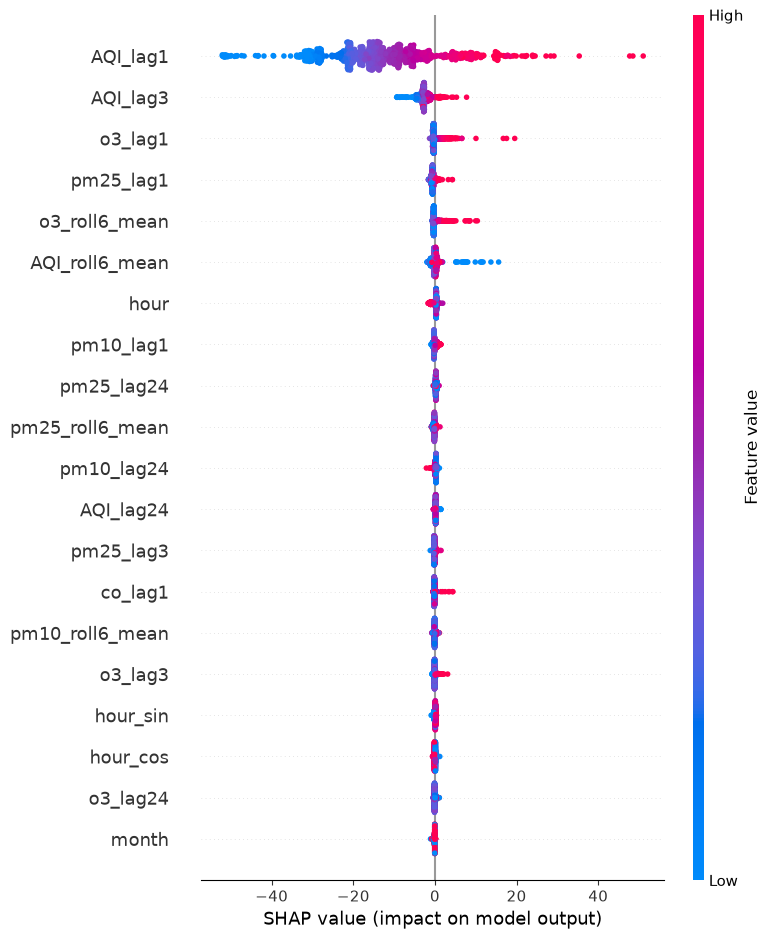

In [3]:
# Summary plot

shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.show()

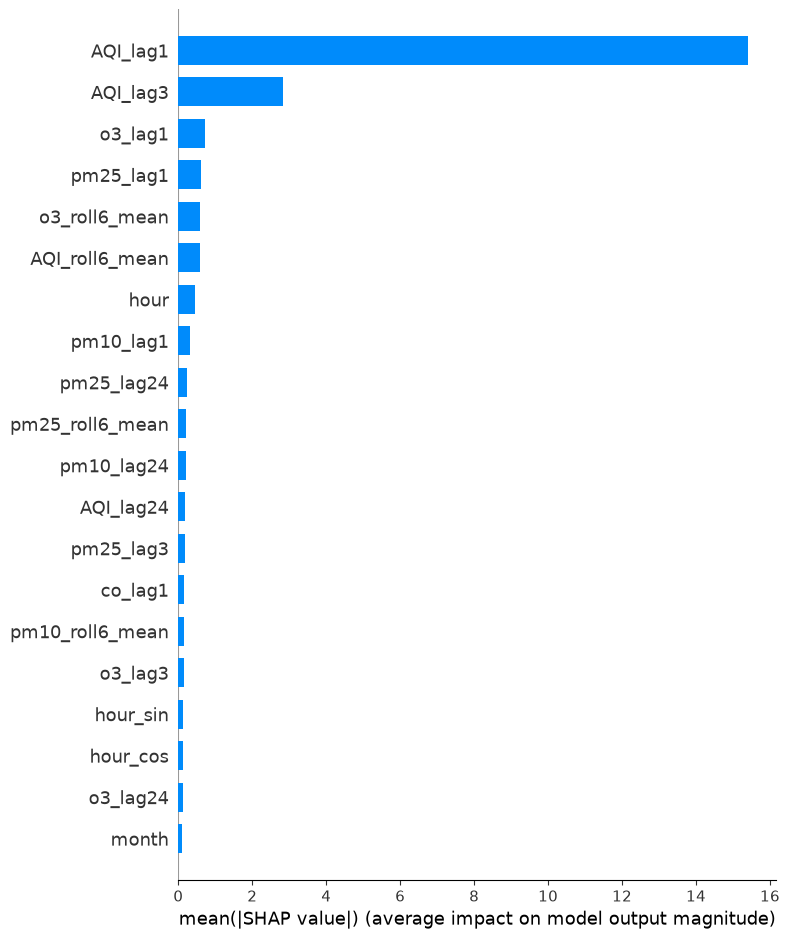

In [4]:
# Plot mean absolute shap value per feature (bar chart)

shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
plt.tight_layout()
plt.show()

Top feature: AQI_lag1


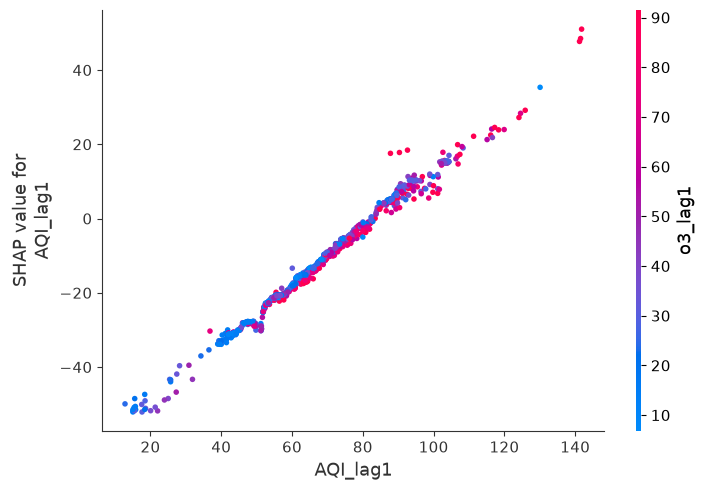

In [5]:
# Plots the relationship between one feature's value and its SHAP impact, colored by the feature it interacts with most.

top_feature = X_test.columns[np.argsort(-np.abs(shap_values.values).mean(axis=0))[0]]
print("Top feature:", top_feature)
shap.dependence_plot(top_feature, shap_values.values, X_test, show=False)
plt.tight_layout()
plt.show()

Actual AQI: 68.5625
Predicted AQI: 69.037994


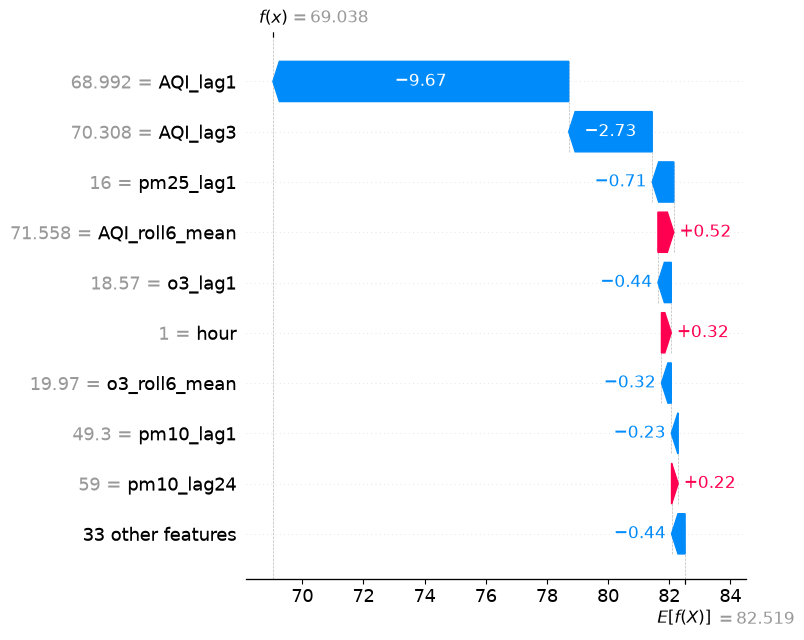

In [6]:
# Pick one test-set row and see exactly which features pushed its predicted AQI up or down.

row_idx = 0
print("Actual AQI:", test['AQI'].iloc[row_idx])
print("Predicted AQI:", reg.predict(X_test.iloc[[row_idx]])[0])

shap.plots.waterfall(shap_values[row_idx], show=False)
plt.tight_layout()
plt.show()